# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Lifestyle Performance Dataset](https://www.kaggle.com/datasets/rafi003/student-lifestyle-and-academic-performance-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.


# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_lifestyle_performance_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77


## last Five row

In [4]:
df.tail()

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
995,24,IT,4.60,5.26,4.23,12.64,Non-Veg,82.95,7.12,Day Scholar,69.63,6.65
996,17,IT,4.02,6.55,3.88,2.86,Non-Veg,89.29,4.19,Hosteller,66.97,7.77
997,25,CSE,4.28,8.43,4.64,0.00,Veg,74.57,2.80,Day Scholar,80.52,8.04
998,23,Civil,6.42,6.06,4.84,10.08,Non-Veg,91.57,6.76,Day Scholar,77.48,7.24
999,19,Mechanical,2.35,8.30,7.18,1.91,Veg,67.01,1.22,Hosteller,68.44,7.89


## Shape of our dataset

In [5]:
df.shape

(1000, 12)

## List out all columns

In [6]:
df.columns

Index(['Age', 'Branch', 'Study_Hours_per_Day', 'Sleep_Hours',
       'Screen_Time_Hours', 'Gym_Hours_per_Week', 'Diet_Type',
       'Attendance_Percentage', 'Stress_Level_1_to_10', 'Residence',
       'Internal_Marks', 'CGPA'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Age                        int64
Branch                    object
Study_Hours_per_Day      float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Gym_Hours_per_Week       float64
Diet_Type                 object
Attendance_Percentage    float64
Stress_Level_1_to_10     float64
Residence                 object
Internal_Marks           float64
CGPA                     float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Branch                 1000 non-null   object 
 2   Study_Hours_per_Day    1000 non-null   float64
 3   Sleep_Hours            1000 non-null   float64
 4   Screen_Time_Hours      1000 non-null   float64
 5   Gym_Hours_per_Week     1000 non-null   float64
 6   Diet_Type              1000 non-null   object 
 7   Attendance_Percentage  1000 non-null   float64
 8   Stress_Level_1_to_10   1000 non-null   float64
 9   Residence              1000 non-null   object 
 10  Internal_Marks         1000 non-null   float64
 11  CGPA                   1000 non-null   float64
dtypes: float64(8), int64(1), object(3)
memory usage: 93.9+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Age                      0
Branch                   0
Study_Hours_per_Day      0
Sleep_Hours              0
Screen_Time_Hours        0
Gym_Hours_per_Week       0
Diet_Type                0
Attendance_Percentage    0
Stress_Level_1_to_10     0
Residence                0
Internal_Marks           0
CGPA                     0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.898000,4.037970,6.525030,4.95191,7.311910,80.084340,4.582850,65.922380,7.319300
std,2.603916,1.434691,1.205664,1.97294,4.949333,8.578242,2.024595,10.123247,0.953812
min,17.000000,0.500000,3.000000,1.00000,0.000000,54.660000,1.000000,35.000000,4.000000
25%,19.000000,3.020000,5.710000,3.49000,3.445000,74.307500,3.095000,59.330000,6.690000
50%,21.000000,4.090000,6.515000,4.95500,6.975000,80.210000,4.540000,65.600000,7.300000
75%,23.000000,5.030000,7.380000,6.37250,10.780000,86.165000,5.962500,72.547500,7.990000
max,25.000000,8.050000,10.000000,10.84000,21.000000,100.000000,10.000000,93.930000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

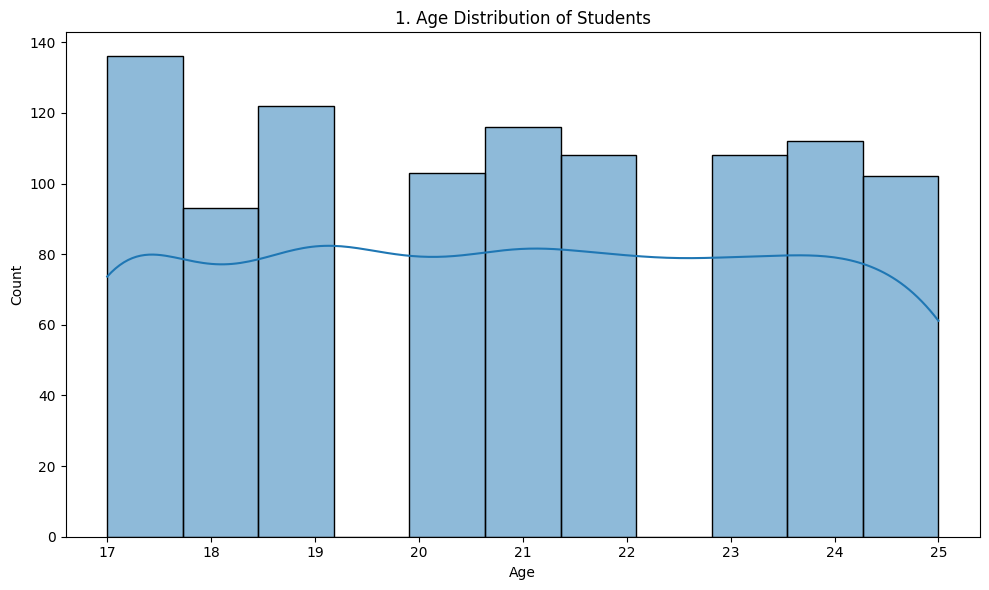

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Students')
show_fig()
plot_no += 1

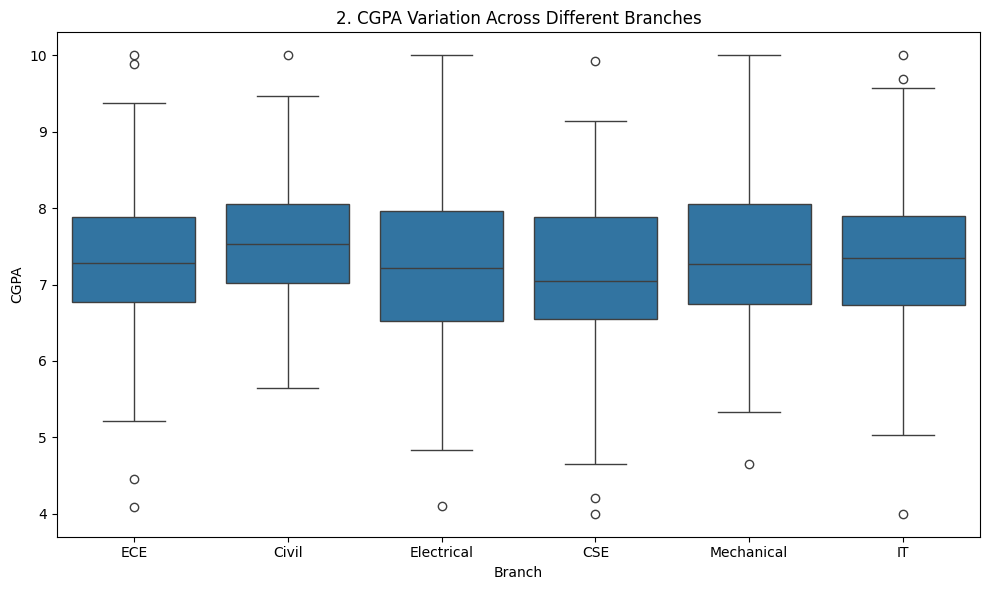

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Branch', y='CGPA', data=df)
plt.title(f'{plot_no}. CGPA Variation Across Different Branches')
show_fig()
plot_no += 1

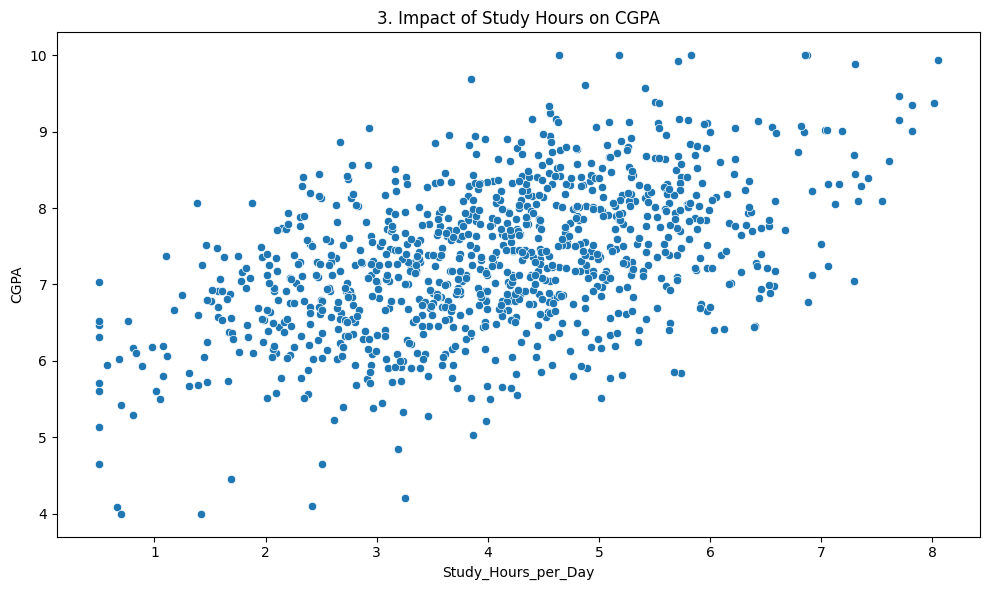

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Study_Hours_per_Day', y='CGPA', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on CGPA')
show_fig()
plot_no += 1

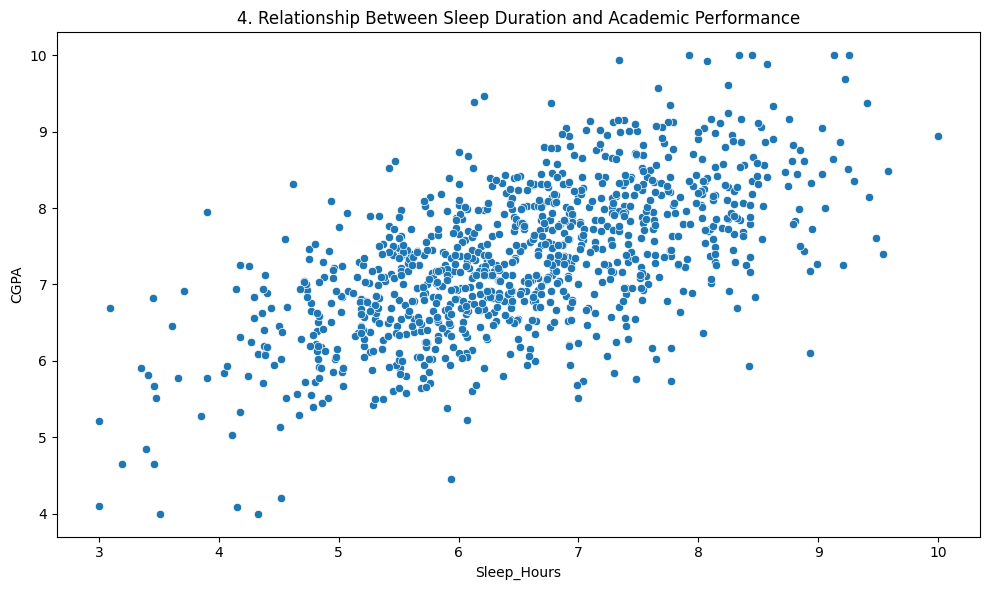

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sleep_Hours', y='CGPA', data=df)
plt.title(f'{plot_no}. Relationship Between Sleep Duration and Academic Performance')
show_fig()
plot_no += 1

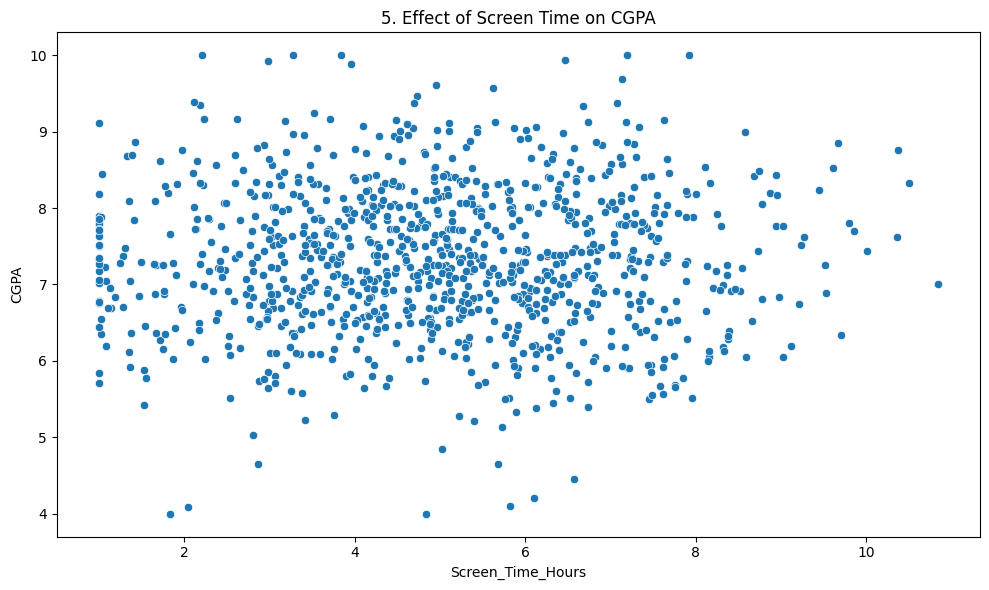

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Screen_Time_Hours', y='CGPA', data=df)
plt.title(f'{plot_no}. Effect of Screen Time on CGPA')
show_fig()
plot_no += 1

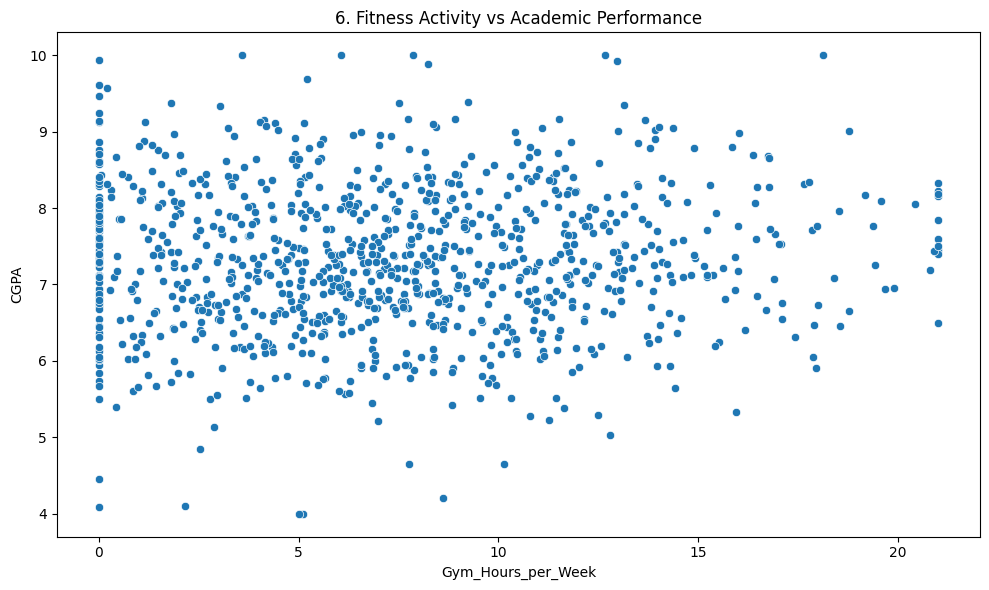

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Gym_Hours_per_Week', y='CGPA', data=df)
plt.title(f'{plot_no}. Fitness Activity vs Academic Performance')
show_fig()
plot_no += 1

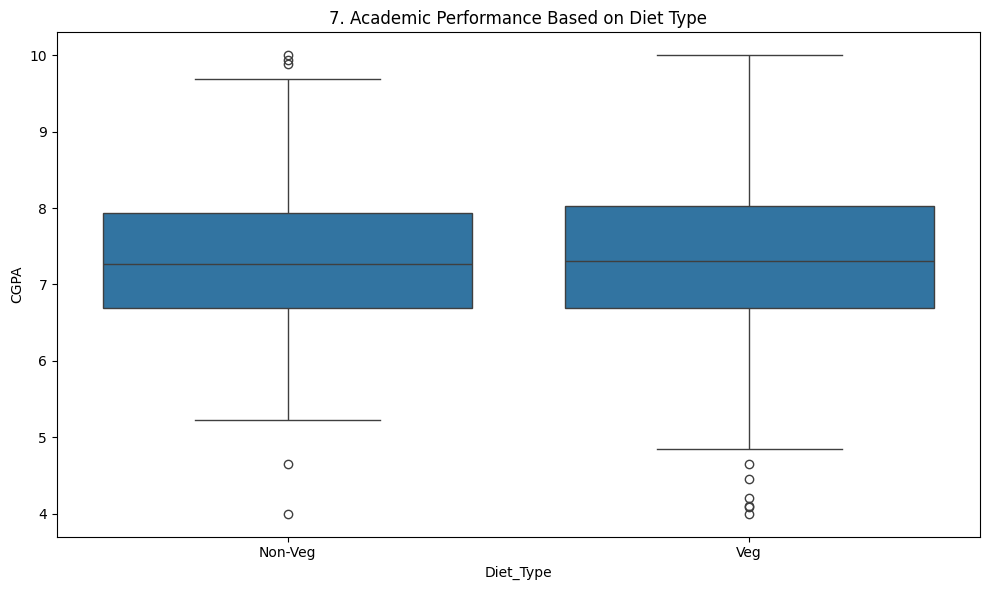

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Diet_Type', y='CGPA', data=df)
plt.title(f'{plot_no}. Academic Performance Based on Diet Type')
show_fig()
plot_no += 1

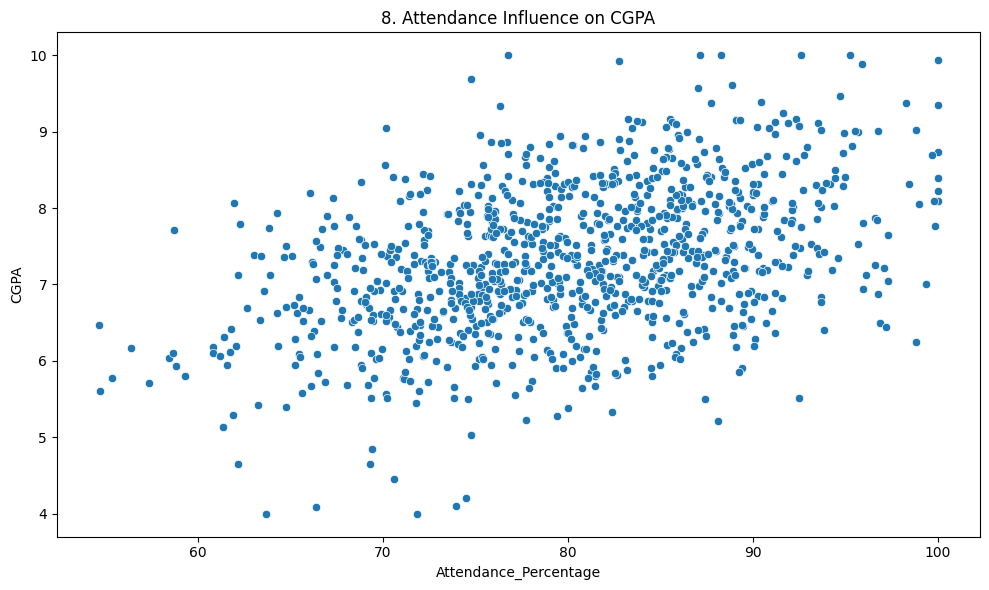

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Attendance_Percentage', y='CGPA', data=df)
plt.title(f'{plot_no}. Attendance Influence on CGPA')
show_fig()
plot_no += 1

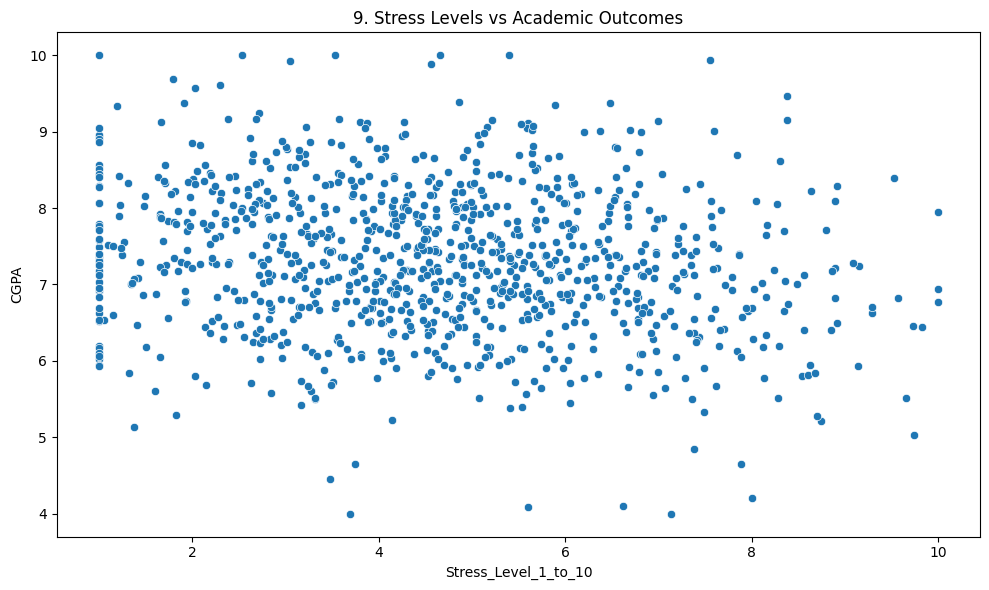

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Stress_Level_1_to_10', y='CGPA', data=df)
plt.title(f'{plot_no}. Stress Levels vs Academic Outcomes')
show_fig()
plot_no += 1

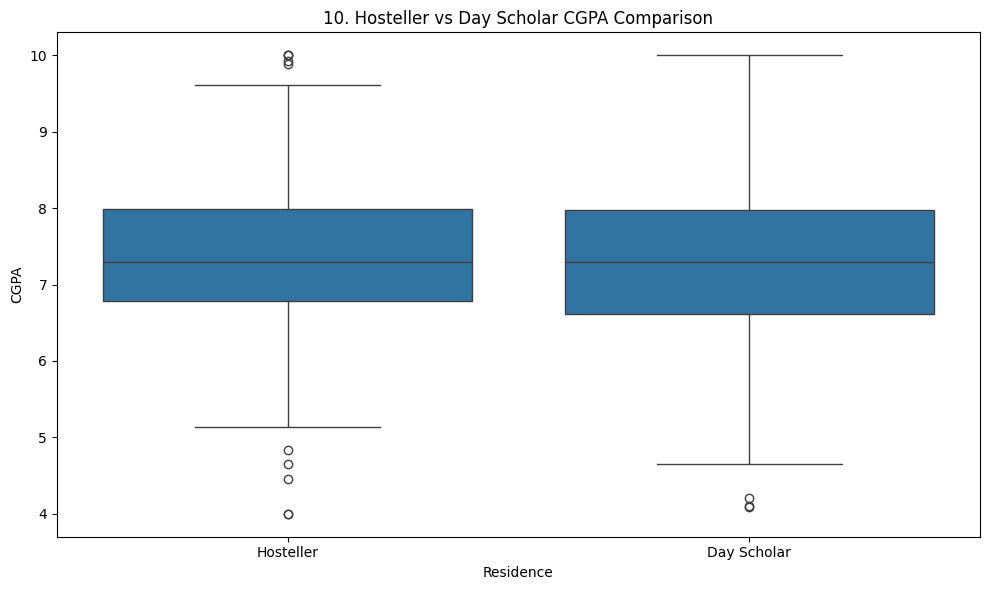

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Residence', y='CGPA', data=df)
plt.title(f'{plot_no}. Hosteller vs Day Scholar CGPA Comparison')
show_fig()
plot_no += 1

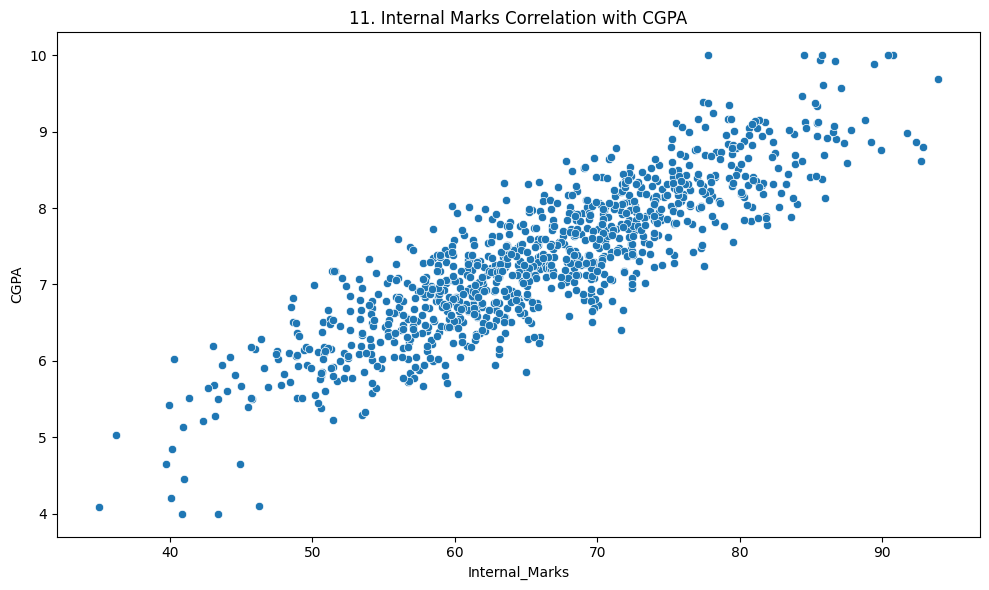

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Internal_Marks', y='CGPA', data=df)
plt.title(f'{plot_no}. Internal Marks Correlation with CGPA')
show_fig()
plot_no += 1

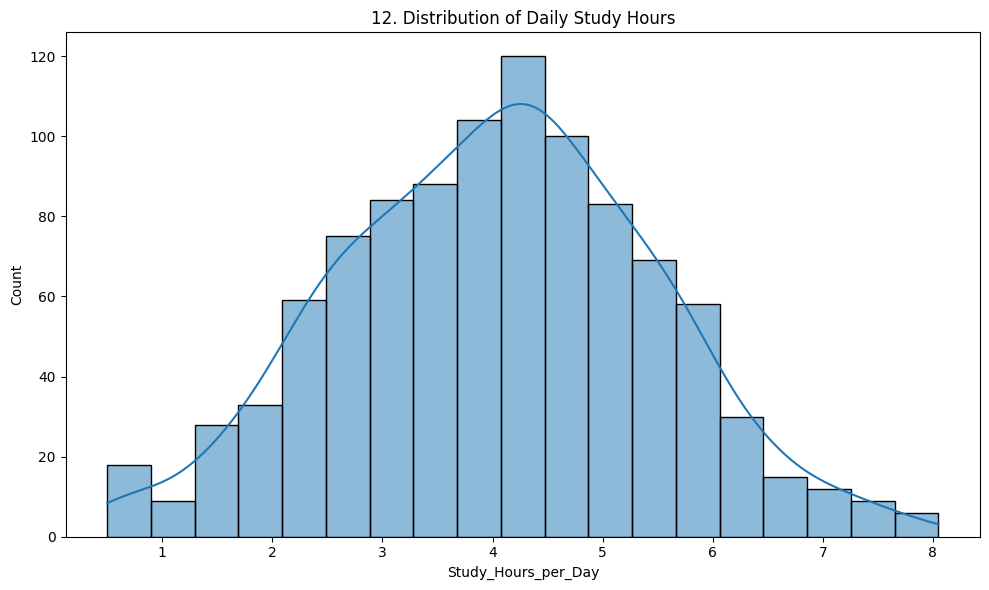

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Study_Hours_per_Day'], kde=True)
plt.title(f'{plot_no}. Distribution of Daily Study Hours')
show_fig()
plot_no += 1

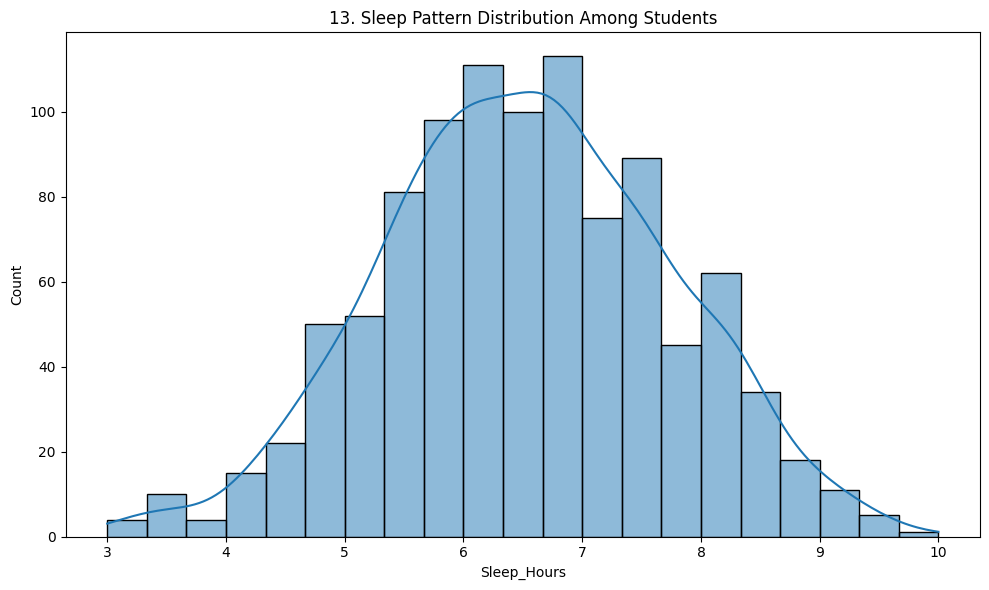

In [25]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Sleep_Hours'], kde=True)
plt.title(f'{plot_no}. Sleep Pattern Distribution Among Students')
show_fig()
plot_no += 1

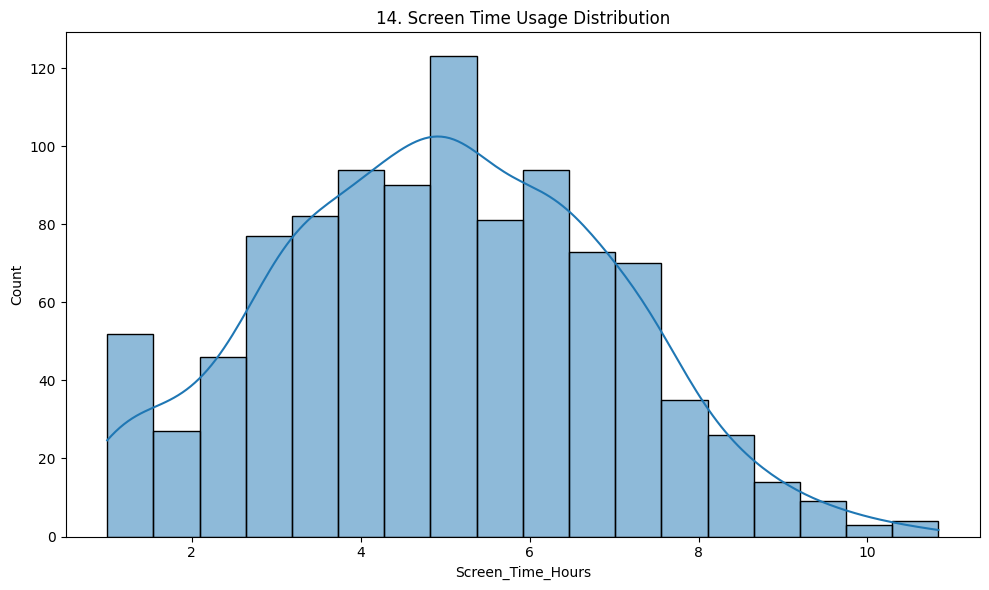

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Screen_Time_Hours'], kde=True)
plt.title(f'{plot_no}. Screen Time Usage Distribution')
show_fig()
plot_no += 1

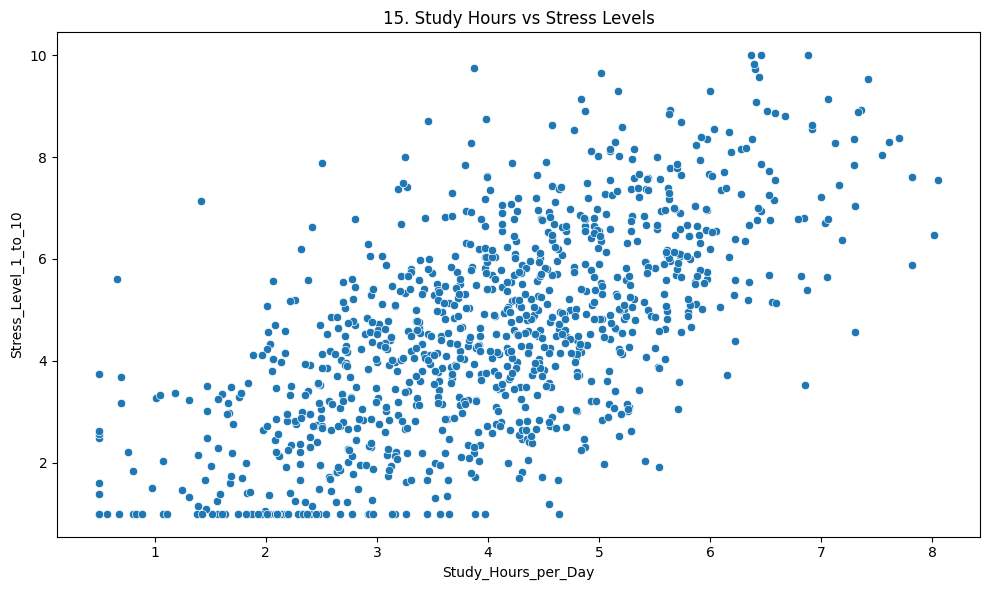

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Study_Hours_per_Day', y='Stress_Level_1_to_10', data=df)
plt.title(f'{plot_no}. Study Hours vs Stress Levels')
show_fig()
plot_no += 1

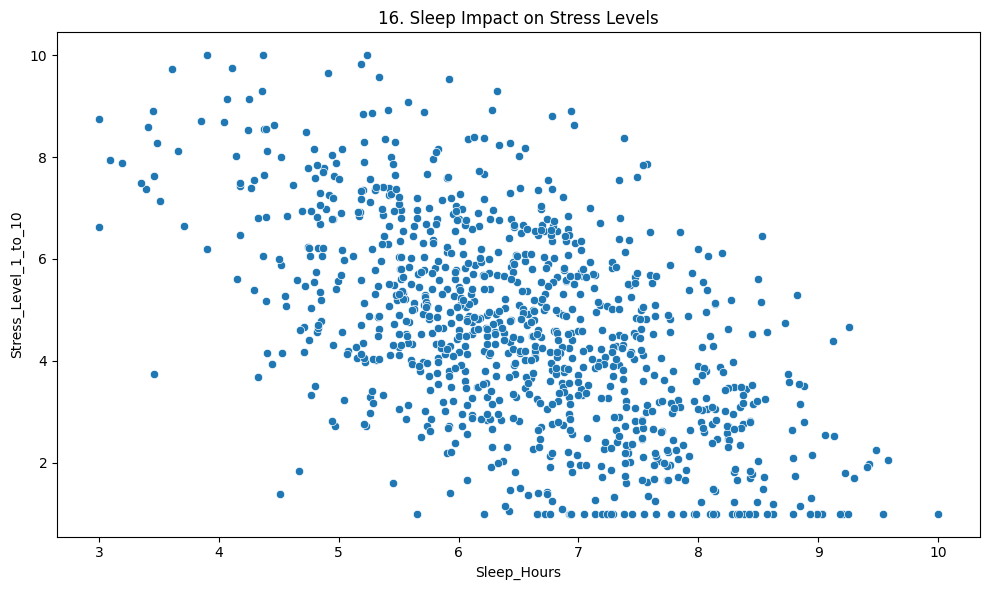

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Sleep_Hours', y='Stress_Level_1_to_10', data=df)
plt.title(f'{plot_no}. Sleep Impact on Stress Levels')
show_fig()
plot_no += 1

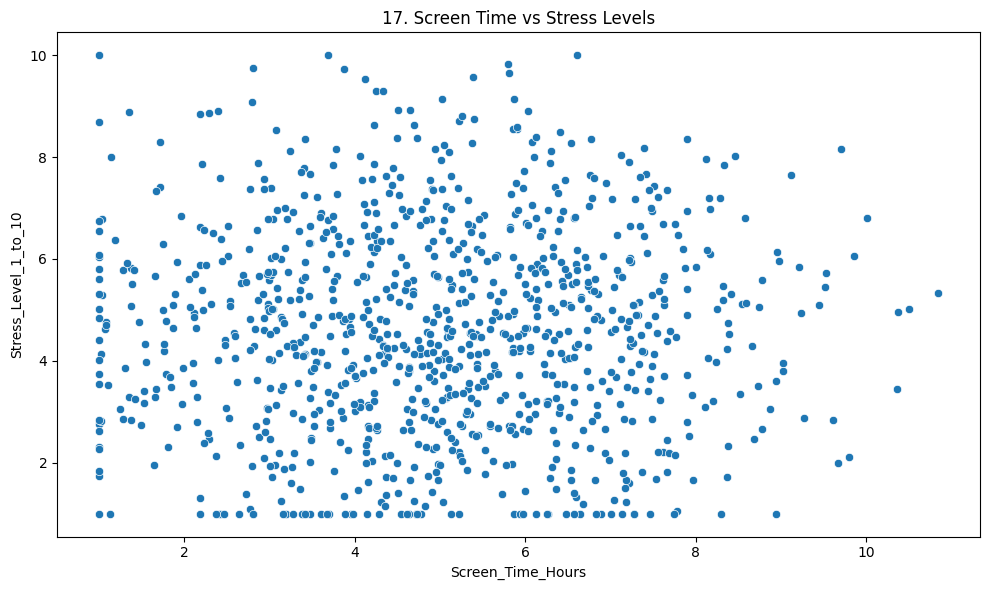

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Screen_Time_Hours', y='Stress_Level_1_to_10', data=df)
plt.title(f'{plot_no}. Screen Time vs Stress Levels')
show_fig()
plot_no += 1

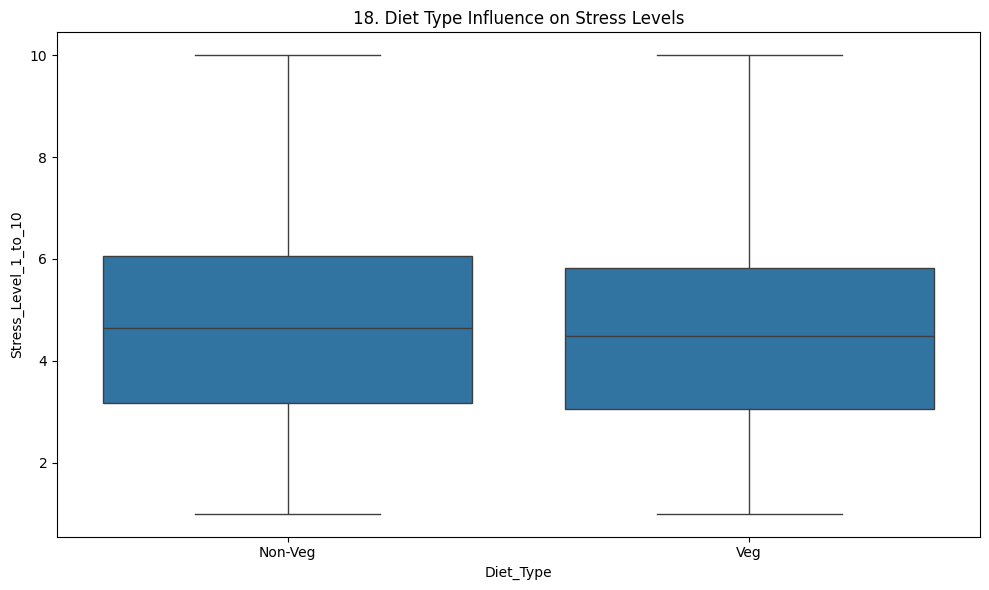

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Diet_Type', y='Stress_Level_1_to_10', data=df)
plt.title(f'{plot_no}. Diet Type Influence on Stress Levels')
show_fig()
plot_no += 1

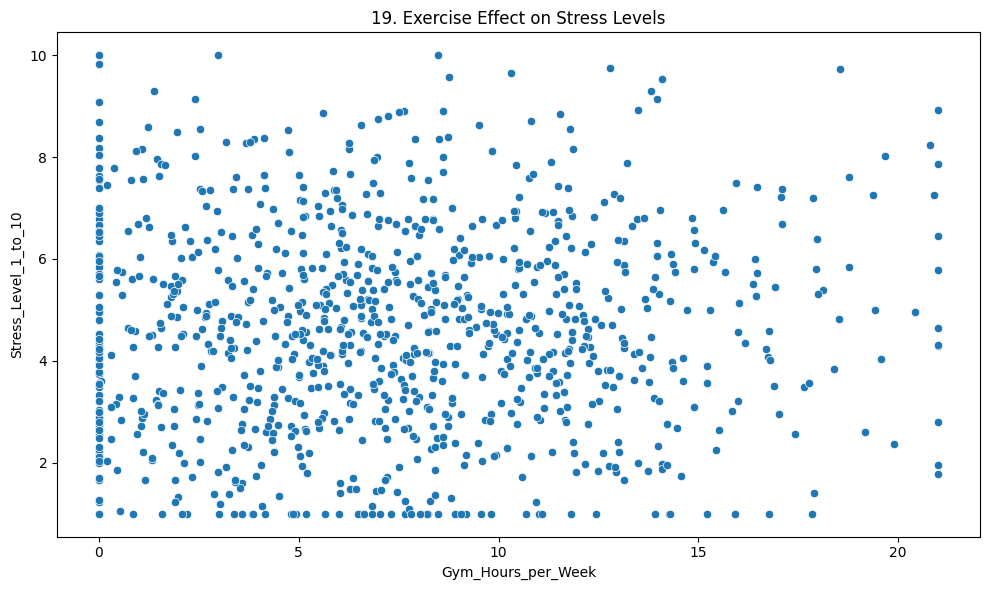

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Gym_Hours_per_Week', y='Stress_Level_1_to_10', data=df)
plt.title(f'{plot_no}. Exercise Effect on Stress Levels')
show_fig()
plot_no += 1

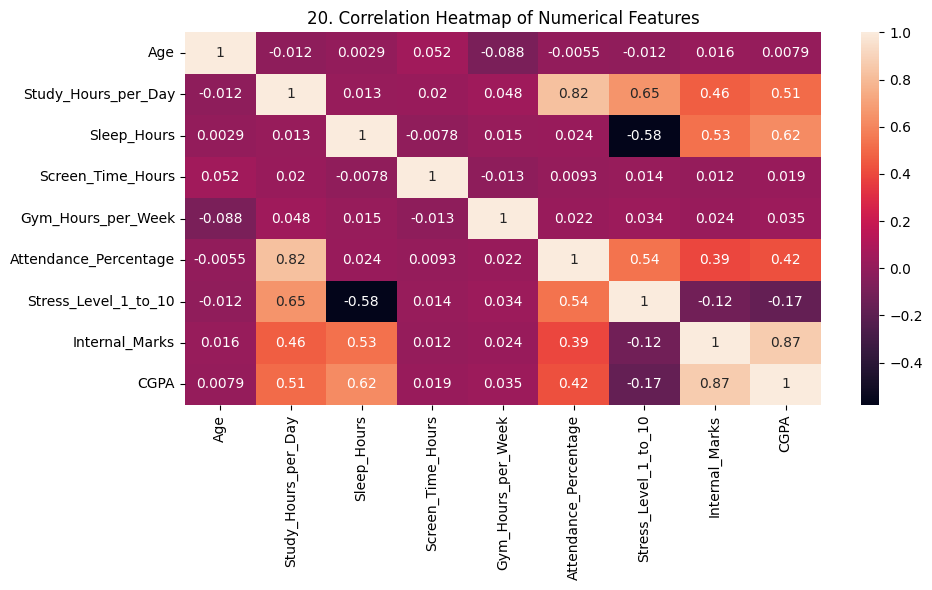

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## convert categorical columns into numeric using encoding

In [33]:
df_encoded = pd.get_dummies(df, drop_first=True)

## define features and target

In [34]:
X = df_encoded.drop('CGPA', axis=1)
y = df_encoded['CGPA']

## split dataset into train and test

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train linear regression model

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## make predictions

In [38]:
y_pred = model.predict(X_test)

## print model accuracy

In [39]:
print("Model Accuracy (R2 Score):", r2_score(y_test, y_pred))

Model Accuracy (R2 Score): 0.8799002274664041


## plot actual vs predicted values

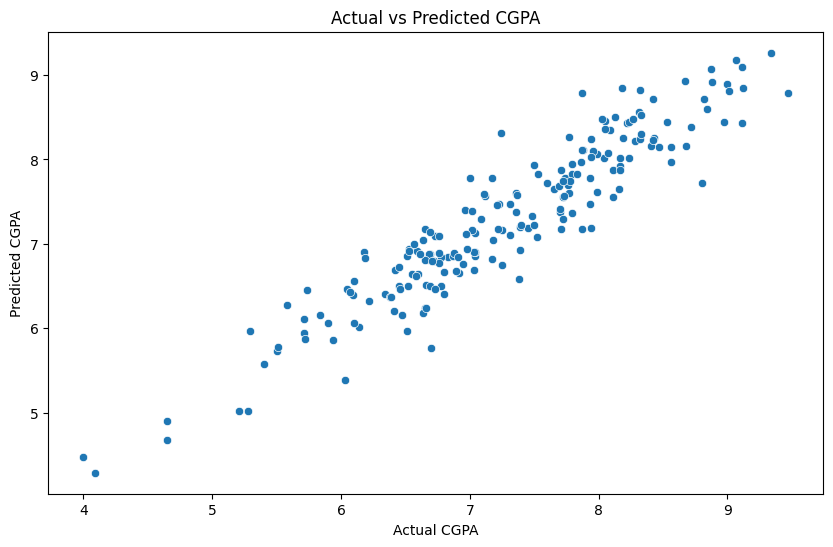

In [40]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.title("Actual vs Predicted CGPA")
plt.show()